In [14]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_avellaneda_stoikov(
    T,               # 총 시뮬레이션 기간(단위: 일, 시간 등)
    dt,             # 시간 스텝
    S0,            # 초기 가격
    sigma,           # 가격 변동성(단위: 예시)
    q0,                # 초기 재고
    gamma,           # 위험회피계수 (Risk aversion)
    A_,              # 체결률 모델 파라미터 A
    k_,              # 체결률 모델 파라미터 k
    inv_limit         # 재고 한도(절대값)
):


    np.random.seed()

    steps = int(T / dt)
    times = np.linspace(0, T, steps+1)

    # 시세, 재고, 현금흐름(PnL) 추적
    S = np.zeros(steps+1)
    S[0] = S0

    q = np.zeros(steps+1)  # 재고(Inventory)
    q[0] = q0

    cash = np.zeros(steps+1)  # 현금 or realized PnL
    cash[0] = 0.0

    # HJB 방정식 풀거나 반(半)폐쇄형 솔루션 등을 사용할 수 있음.
    # 여기서는 "재고가 많을수록 스프레드를 넓힘"이라는 간단한 규칙만 반영

    for t in range(steps):
        dW = np.random.normal(0, 1)  # 표준정규
        dS = sigma * np.sqrt(dt) * dW
        S[t+1] = max(0, S[t] + dS)

        # 재고에 따른 "예약가격"과 "스프레드" 설정 (매우 단순화) ---

        reservation_price = S[t] - gamma * q[t]

        # 재고가 많을수록(양수든 음수든) 스프레드를 넓히는 식

        base_spread = 1.0
        spread_slope = 0.1
        current_spread = base_spread + spread_slope * abs(q[t])

        # 이 스프레드를 양쪽에 대칭으로 나눈다(매수/매도)
        a_t = current_spread / 2.0  # ask 쪽 스프레드
        b_t = current_spread / 2.0  # bid 쪽 스프레드

        # 실제 호가 가격
        ask_price = reservation_price + a_t
        bid_price = reservation_price - b_t

        # λ^+(a) = A * exp(-k * a), λ^-(b) = A * exp(-k * b)
        lam_plus = A_ * np.exp(-k_ * a_t)  # 매도 체결률(ask 쪽)
        lam_minus = A_ * np.exp(-k_ * b_t) # 매수 체결률(bid 쪽)

        # 아주 간단히, dt 동안에는 "Poisson(λ * dt)" 분포에서
        # 0 or 1회 체결된다고 가정. (멀티 체결은 생략)

        # 매도 체결 발생 여부
        trade_plus = np.random.poisson(lam_plus * dt) > 0  # True/False
        # 매수 체결 발생 여부
        trade_minus = np.random.poisson(lam_minus * dt) > 0

        q_next = q[t]
        cash_next = cash[t]

        if trade_plus:
            # ask_price로 1단위 체결
            if abs(q_next - 1) <= inv_limit:
                q_next -= 1
                cash_next += ask_price

        if trade_minus:
            # bid_price로 1단위 체결
            if abs(q_next + 1) <= inv_limit:
                q_next += 1
                cash_next -= bid_price

        q[t+1] = q_next
        cash[t+1] = cash_next

    final_pnl = cash[-1] + q[-1] * S[-1]

    return times, S, q, cash, final_pnl


최종 PnL: 62.24
최종 재고(q): -10.00, 최종 가격(S): 102.76


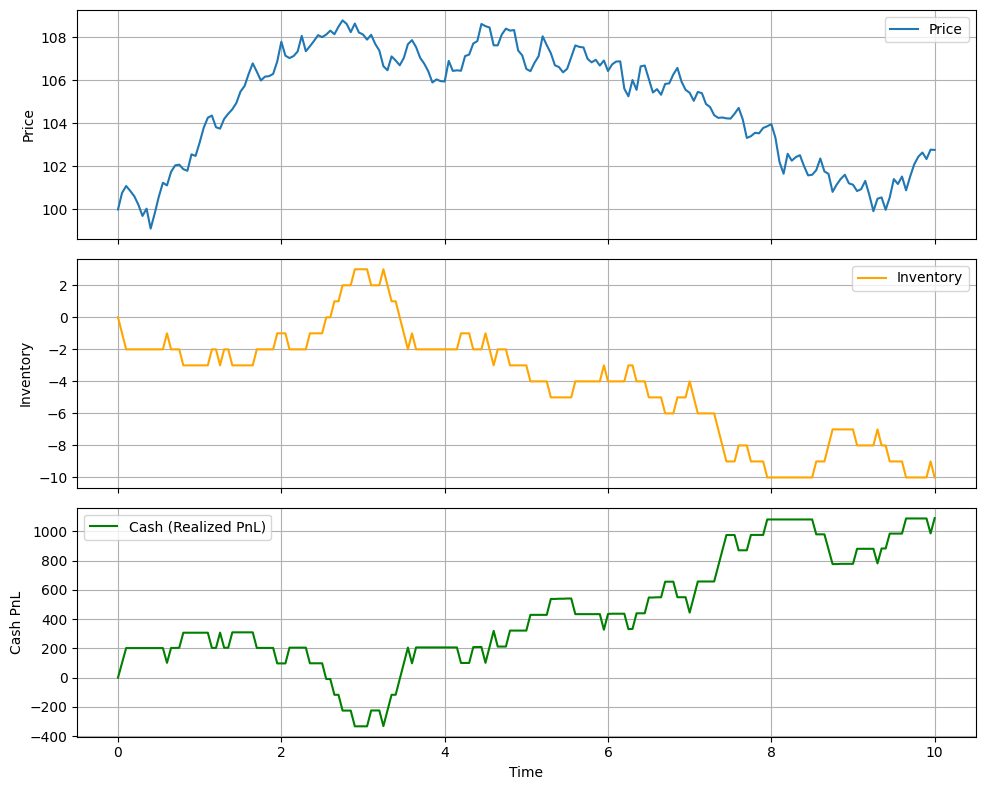

In [16]:
T = 10.0
dt = 0.05
S0 = 100.0
sigma = 2.0
q0=0
gamma = 0.1
A_ = 10.0
k_ = 1.2
inv_limit = 10

times, S, q, cash, final_pnl = simulate_avellaneda_stoikov(
    T=T, dt=dt, S0=S0, sigma=sigma, q0=0,
    gamma=gamma, A_=A_, k_=k_, inv_limit=inv_limit
)

print(f"최종 PnL: {final_pnl:.2f}")
print(f"최종 재고(q): {q[-1]:.2f}, 최종 가격(S): {S[-1]:.2f}")

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(times, S, label="Price")
axs[0].set_ylabel("Price")

axs[1].plot(times, q, label="Inventory", color="orange")
axs[1].set_ylabel("Inventory")

axs[2].plot(times, cash, label="Cash (Realized PnL)", color="green")
axs[2].set_ylabel("Cash PnL")
axs[2].set_xlabel("Time")

for ax in axs:
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()